

<font face="Times New Roman" size=5>
<div dir=rtl align="center">


<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Nano
</font>
<br>
<font color="#008080" size=6>
Introduction to Machine Learning
</font>

<hr/>
<font color="#80a080" size=5>
Course Home Work 5
<br>
</font>
<font size=5>
Instructor: Dr. Ebrahim Pour
<br>
</font>
<font size=4>
Spring 2026
<br>
</font>

> **Student**:
>
> Kian Mamdouhi: 400108066

###  Data Extraction

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.kernel_ridge import KernelRidge

# Data

filepath = "C:/term10\ML/tamrin\HW5\Data.xlsx"

# Target (1000 point)
df_target = pd.read_excel(filepath, sheet_name="target")
x_target = df_target["sin2φ"].to_numpy(dtype=float)
y_target = df_target["2θ(degree)"].to_numpy(dtype=float)

mask_t = np.isfinite(x_target) & np.isfinite(y_target)
x_target, y_target = x_target[mask_t], y_target[mask_t]

# Control (1000 point)
df_control = pd.read_excel(filepath, sheet_name="control")
x_control = df_control["sin2φ.1"].to_numpy(dtype=float)
y_control = df_control["2θ(degree).1"].to_numpy(dtype=float)

mask_c = np.isfinite(x_control) & np.isfinite(y_control)
x_control, y_control = x_control[mask_c], y_control[mask_c]

# Checking
if len(x_target) != 1000 or len(y_target) != 1000:
    raise ValueError(f"Target data is not 1000 points. Got {len(x_target)}")

if len(x_control) != 1000 or len(y_control) != 1000:
    raise ValueError(f"Control data is not 1000 points. Got {len(x_control)}")

print("Target:", len(x_target), "points")
print("Control:", len(x_control), "points")




Target: 1000 points
Control: 1000 points


### Linear Regression

In [10]:
def linear_regression_manual(x, y):
    # Data preparation
    x = np.asarray(x).reshape(-1)
    y = np.asarray(y).reshape(-1)

    if x.shape[0] != y.shape[0]:
        raise ValueError("x and y must have the same length.")

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    if len(x) < 2:
        raise ValueError("Need at least 2 valid points to fit a line.")

    x_mean = x.mean()
    y_mean = y.mean()

    denom = np.sum((x - x_mean) ** 2)
    if denom == 0:
        raise ValueError("All x values are identical; cannot fit a unique line.")

    w1 = np.sum((x - x_mean) * (y - y_mean)) / denom
    w0 = y_mean - w1 * x_mean

    # error
    y_hat = w0 + w1 * x
    residuals = y - y_hat

    SSE = float(np.sum(residuals ** 2))
    SAE = float(np.sum(np.abs(residuals)))

    return w0, w1, SSE, SAE, y_hat


=== TARGET (Manual LR) ===
w0 = 31.923319412538604
w1 (slope) = -0.021479004003466796
SSE = 8.331130217590559e-09
SAE = 0.0024996857642918258

=== CONTROL (Manual LR) ===
w0 = 31.95027256661863
w1 (slope) = -0.04289469977981032
SSE = 8.283758515198622e-09
SAE = 0.002488846699616687


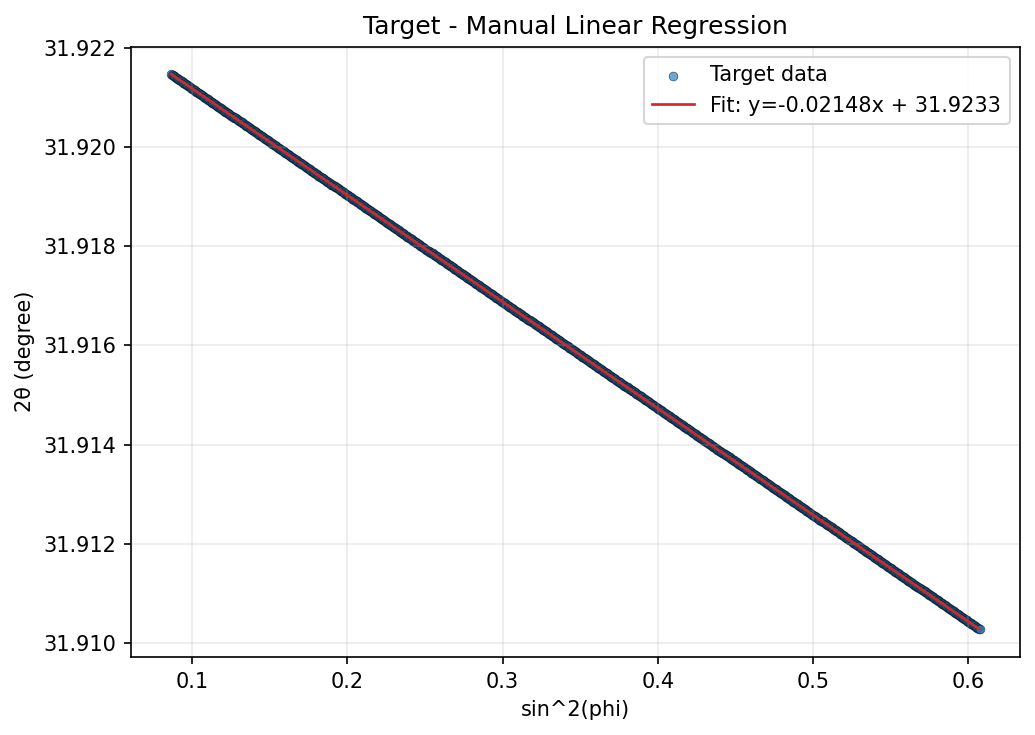

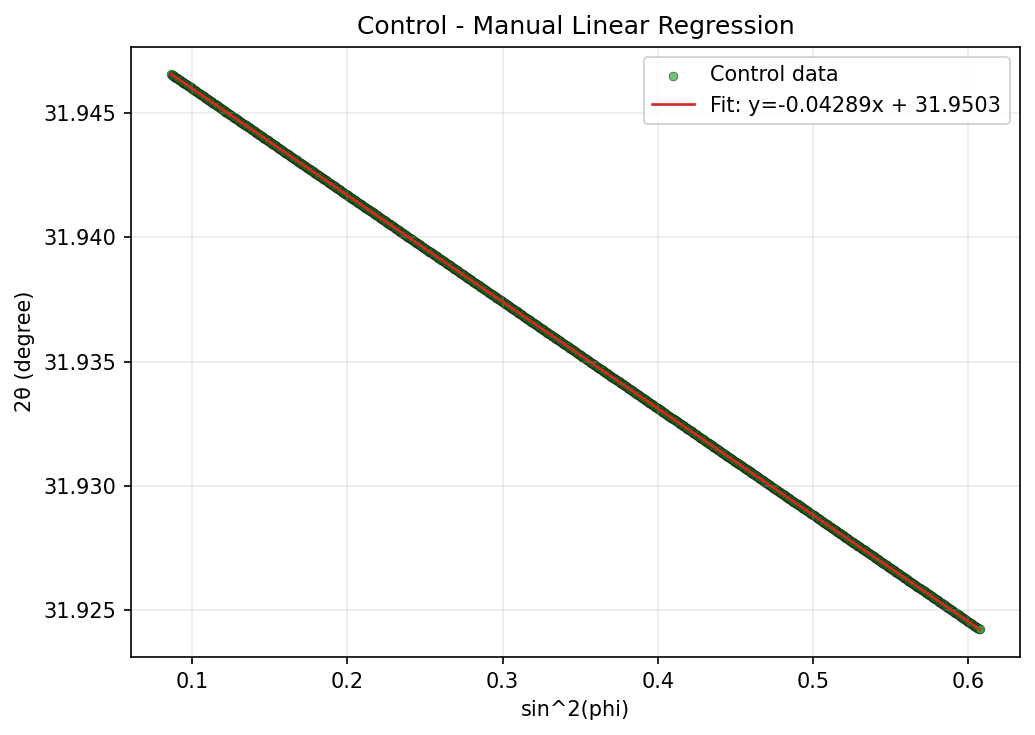

In [14]:
# Applying linear regression

w0_t, w1_t, SSE_t, SAE_t, yhat_t = linear_regression_manual(x_target, y_target)
w0_c, w1_c, SSE_c, SAE_c, yhat_c = linear_regression_manual(x_control, y_control)

print("=== TARGET (Manual LR) ===")
print(f"w0 = {w0_t}")
print(f"w1 (slope) = {w1_t}")
print(f"SSE = {SSE_t}")
print(f"SAE = {SAE_t}")

print("\n=== CONTROL (Manual LR) ===")
print(f"w0 = {w0_c}")
print(f"w1 (slope) = {w1_c}")
print(f"SSE = {SSE_c}")
print(f"SAE = {SAE_c}")

# Target
xs_t = np.linspace(np.min(x_target), np.max(x_target), 400)
ys_t = w0_t + w1_t * xs_t

m_t = f"{w1_t:.5f}"
b_t = f"{abs(w0_t):.4f}"
sign_t = "+" if w0_t >= 0 else "-"
eq_t = f"y={m_t}x {sign_t} {b_t}"

plt.figure(figsize=(7, 5), dpi=150)
plt.scatter(
    x_target, y_target,
    s=18, alpha=0.65,
    color="tab:blue", edgecolors="k", linewidths=0.3,
    label="Target data"
)
plt.plot(
    xs_t, ys_t,
    color="tab:red", linewidth=1.3,
    label=f"Fit: {eq_t}"
)
plt.xlabel("sin^2(phi)")
plt.ylabel("2θ (degree)")
plt.title("Target - Manual Linear Regression")
plt.grid(True, alpha=0.25)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# Control
xs_c = np.linspace(np.min(x_control), np.max(x_control), 400)
ys_c = w0_c + w1_c * xs_c

m_c = f"{w1_c:.5f}"
b_c = f"{abs(w0_c):.4f}"
sign_c = "+" if w0_c >= 0 else "-"
eq_c = f"y={m_c}x {sign_c} {b_c}"

plt.figure(figsize=(7, 5), dpi=150)
plt.scatter(
    x_control, y_control,
    s=18, alpha=0.65,
    color="tab:green", edgecolors="k", linewidths=0.3,
    label="Control data"
)
plt.plot(
    xs_c, ys_c,
    color="tab:red", linewidth=1.3,
    label=f"Fit: {eq_c}"
)
plt.xlabel("sin^2(phi)")
plt.ylabel("2θ (degree)")
plt.title("Control - Manual Linear Regression")
plt.grid(True, alpha=0.25)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


###  MLP

=== TARGET (MLPRegressor) ===
Params: hidden=(10,), act=identity, alpha=0.01, lr=0.001, max_iter=5000
SSE = 1.0458847267530842e-06
SAE = 0.03201590740106397


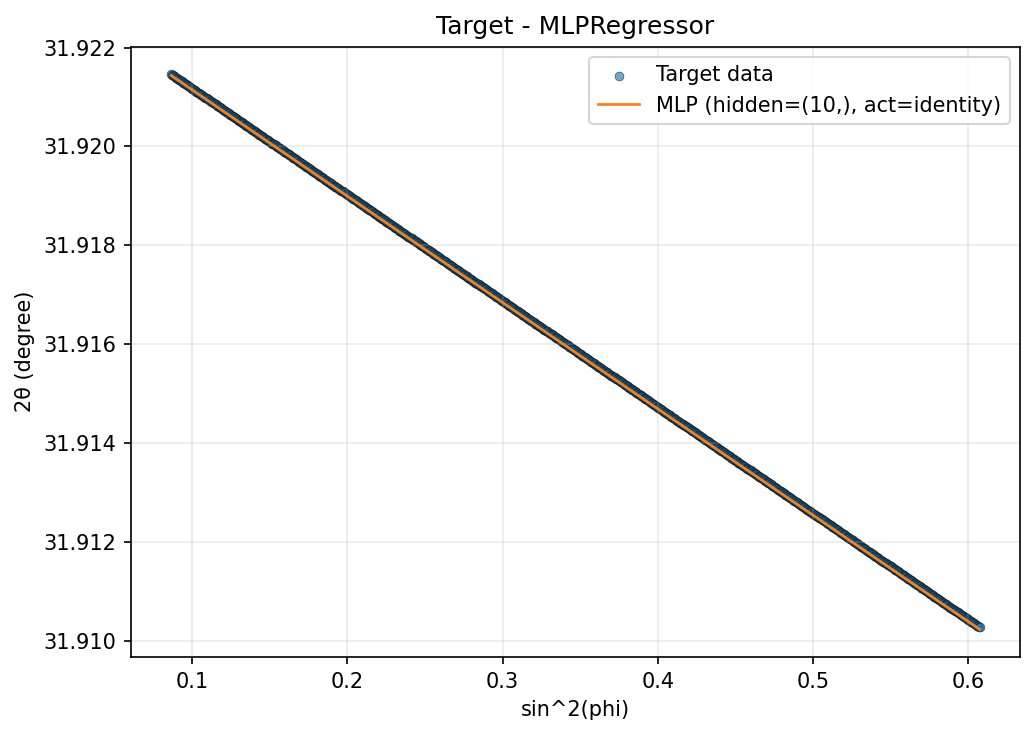


=== CONTROL (MLPRegressor) ===
Params: hidden=(10,), act=identity, alpha=0.01, lr=0.001, max_iter=5000
SSE = 1.5672362903512888e-06
SAE = 0.03930997751777454


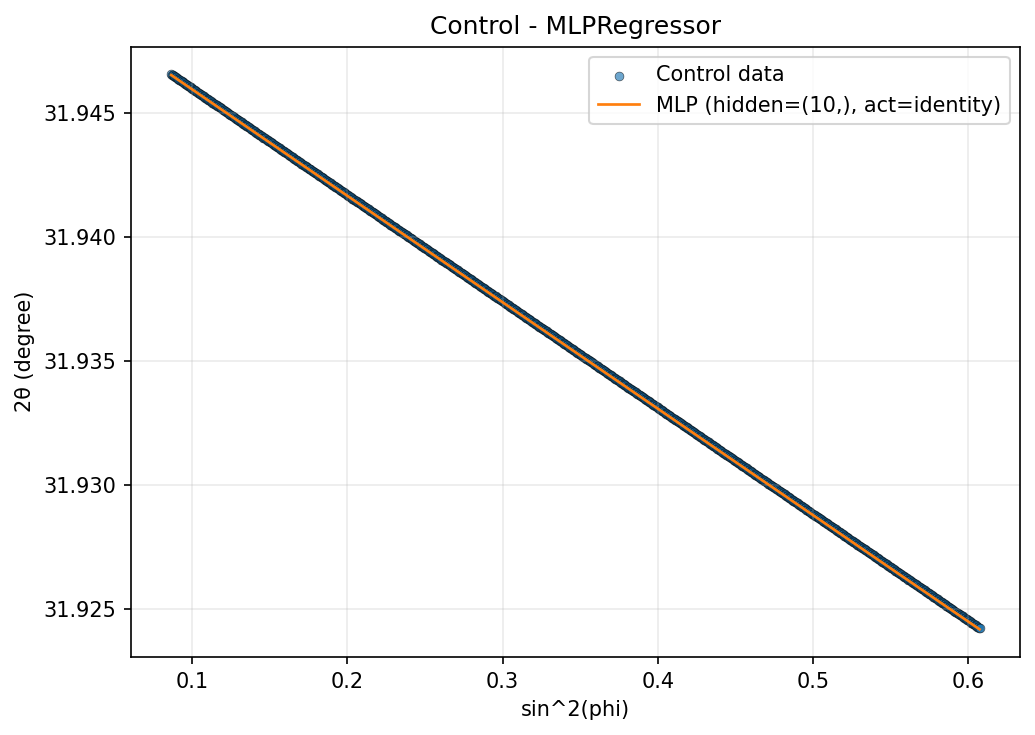

In [17]:

# MLP parameters

hidden = (10,)          # Two hidden layers
activation = "identity"        # For almost linear data
alpha_val = 1e-2           # L2 regularization
max_iter_val = 5000
lr_init = 1e-3
seed = 42

# TARGET: MLP fit + metrics + plot
X_t = x_target.reshape(-1, 1)
y_t = y_target

mlp_t = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=hidden,
        activation=activation,
        solver="adam",
        alpha=alpha_val,
        learning_rate_init=lr_init,
        max_iter=max_iter_val,
        random_state=seed,
        early_stopping=True,     # to handle overfit
        n_iter_no_change=50
    ))
])

mlp_t.fit(X_t, y_t)

yhat_t = mlp_t.predict(X_t)
res_t = y_t - yhat_t
SSE_t = float(np.sum(res_t**2))
SAE_t = float(np.sum(np.abs(res_t)))

print("=== TARGET (MLPRegressor) ===")
print(f"Params: hidden={hidden}, act={activation}, alpha={alpha_val}, lr={lr_init}, max_iter={max_iter_val}")
print(f"SSE = {SSE_t}")
print(f"SAE = {SAE_t}")

# plot
xs_t = np.linspace(x_target.min(), x_target.max(), 400).reshape(-1, 1)
ys_t = mlp_t.predict(xs_t)

plt.figure(figsize=(7, 5), dpi=150)
plt.scatter(
    x_target, y_target,
    s=18, alpha=0.65, color="tab:blue",
    edgecolors="k", linewidths=0.3,
    label="Target data"
)
plt.plot(
    xs_t.ravel(), ys_t,
    color="tab:orange", linewidth=1.3,
    label=f"MLP (hidden={hidden}, act={activation})"
)
plt.xlabel("sin^2(phi)")
plt.ylabel("2θ (degree)")
plt.title("Target - MLPRegressor")
plt.grid(True, alpha=0.25)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


# CONTROL: MLP fit + metrics + plot
X_c = x_control.reshape(-1, 1)
y_c = y_control

mlp_c = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=hidden,
        activation=activation,
        solver="adam",
        alpha=alpha_val,
        learning_rate_init=lr_init,
        max_iter=max_iter_val,
        random_state=seed,
        early_stopping=True,
        n_iter_no_change=50
    ))
])

mlp_c.fit(X_c, y_c)

yhat_c = mlp_c.predict(X_c)
res_c = y_c - yhat_c
SSE_c = float(np.sum(res_c**2))
SAE_c = float(np.sum(np.abs(res_c)))

print("\n=== CONTROL (MLPRegressor) ===")
print(f"Params: hidden={hidden}, act={activation}, alpha={alpha_val}, lr={lr_init}, max_iter={max_iter_val}")
print(f"SSE = {SSE_c}")
print(f"SAE = {SAE_c}")

# plot
xs_c = np.linspace(x_control.min(), x_control.max(), 400).reshape(-1, 1)
ys_c = mlp_c.predict(xs_c)

plt.figure(figsize=(7, 5), dpi=150)
plt.scatter(
    x_control, y_control,
    s=18, alpha=0.65, color="tab:blue",
    edgecolors="k", linewidths=0.3,
    label="Control data"
)
plt.plot(
    xs_c.ravel(), ys_c,
    color="tab:orange", linewidth=1.3,
    label=f"MLP (hidden={hidden}, act={activation})"
)
plt.xlabel("sin^2(phi)")
plt.ylabel("2θ (degree)")
plt.title("Control - MLPRegressor")
plt.grid(True, alpha=0.25)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


###  SVR

 * RBF kernel

=== TARGET (SVR-RBF) ===
Params: C=10.0, epsilon=0.0001, gamma=0.1
SSE = 0.00012136372901594208
SAE = 0.3109746320302129


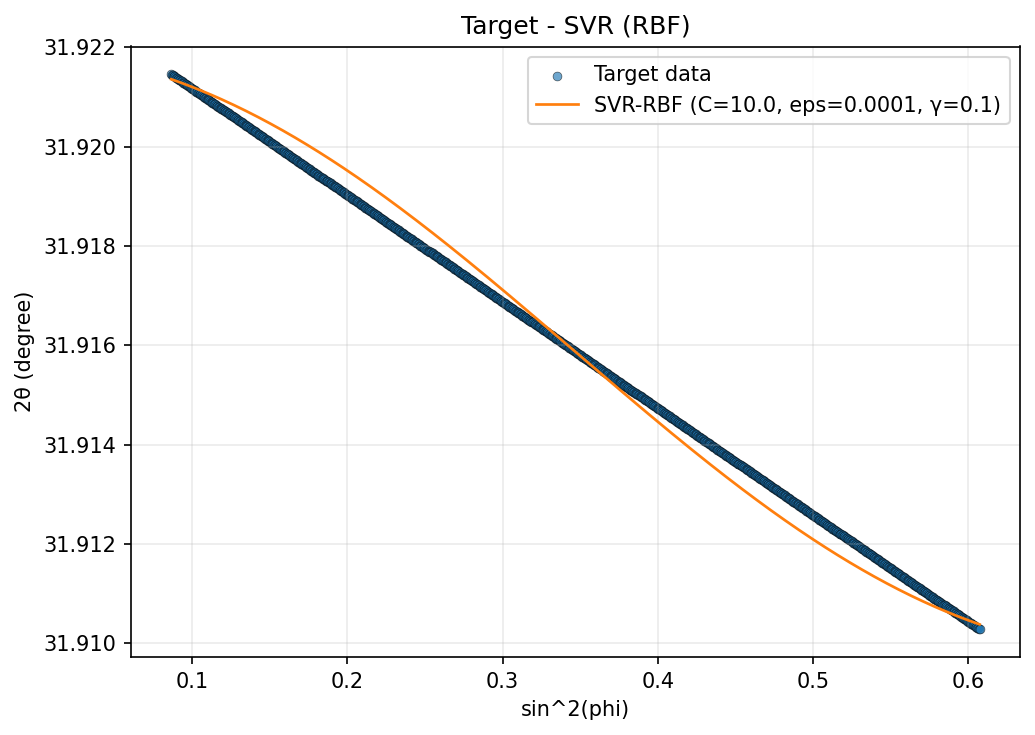


=== CONTROL (SVR-RBF) ===
Params: C=10.0, epsilon=0.0001, gamma=0.1
SSE = 4.055705184085553e-05
SAE = 0.15564867470729027


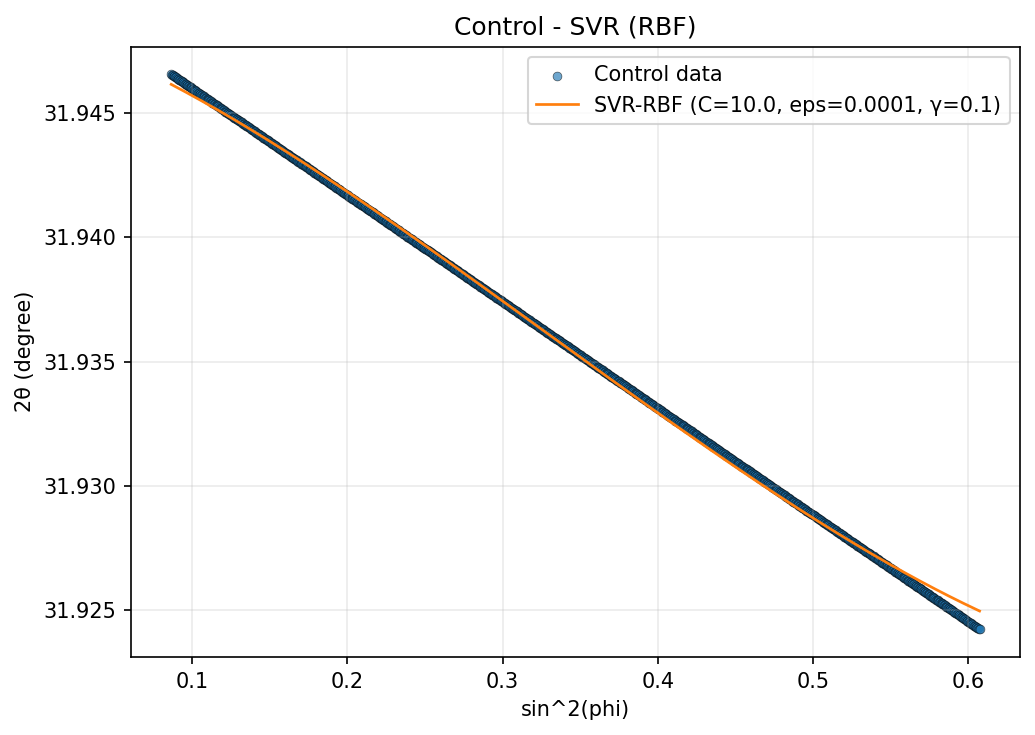

In [18]:

# SVR parameters
C_val = 10.0
epsilon_val = 0.0001
gamma_val = 0.1

# TARGET: SVR fit + metrics + plot
X_t = x_target.reshape(-1, 1)
y_t = y_target

svr_t = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=C_val, epsilon=epsilon_val, gamma=gamma_val))
])
svr_t.fit(X_t, y_t)

yhat_t = svr_t.predict(X_t)
res_t = y_t - yhat_t
SSE_t = float(np.sum(res_t**2))
SAE_t = float(np.sum(np.abs(res_t)))

print("=== TARGET (SVR-RBF) ===")
print(f"Params: C={C_val}, epsilon={epsilon_val}, gamma={gamma_val}")
print(f"SSE = {SSE_t}")
print(f"SAE = {SAE_t}")

# plot
xs_t = np.linspace(x_target.min(), x_target.max(), 400).reshape(-1, 1)
ys_t = svr_t.predict(xs_t)

plt.figure(figsize=(7, 5), dpi=150)
plt.scatter(
    x_target, y_target,
    s=18, alpha=0.65,
    color="tab:blue", edgecolors="k", linewidths=0.3,
    label="Target data"
)
plt.plot(
    xs_t.ravel(), ys_t,
    color="tab:orange", linewidth=1.3,
    label=f"SVR-RBF (C={C_val}, eps={epsilon_val}, γ={gamma_val})"
)
plt.xlabel("sin^2(phi)")
plt.ylabel("2θ (degree)")
plt.title("Target - SVR (RBF)")
plt.grid(True, alpha=0.25)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


# CONTROL: SVR fit + metrics + plot
X_c = x_control.reshape(-1, 1)
y_c = y_control

svr_c = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=C_val, epsilon=epsilon_val, gamma=gamma_val))
])
svr_c.fit(X_c, y_c)

yhat_c = svr_c.predict(X_c)
res_c = y_c - yhat_c
SSE_c = float(np.sum(res_c**2))
SAE_c = float(np.sum(np.abs(res_c)))

print("\n=== CONTROL (SVR-RBF) ===")
print(f"Params: C={C_val}, epsilon={epsilon_val}, gamma={gamma_val}")
print(f"SSE = {SSE_c}")
print(f"SAE = {SAE_c}")

# plot
xs_c = np.linspace(x_control.min(), x_control.max(), 400).reshape(-1, 1)
ys_c = svr_c.predict(xs_c)

plt.figure(figsize=(7, 5), dpi=150)
plt.scatter(
    x_control, y_control,
    s=18, alpha=0.65,
    color="tab:blue", edgecolors="k", linewidths=0.3,
    label="Control data"
)
plt.plot(
    xs_c.ravel(), ys_c,
    color="tab:orange", linewidth=1.3,
    label=f"SVR-RBF (C={C_val}, eps={epsilon_val}, γ={gamma_val})"
)
plt.xlabel("sin^2(phi)")
plt.ylabel("2θ (degree)")
plt.title("Control - SVR (RBF)")
plt.grid(True, alpha=0.25)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


* Linear kernel

=== TARGET (SVR-Linear) ===
Params: C=10.0, epsilon=0.0001
SSE = 3.290429423802915e-06
SAE = 0.04964391349443176


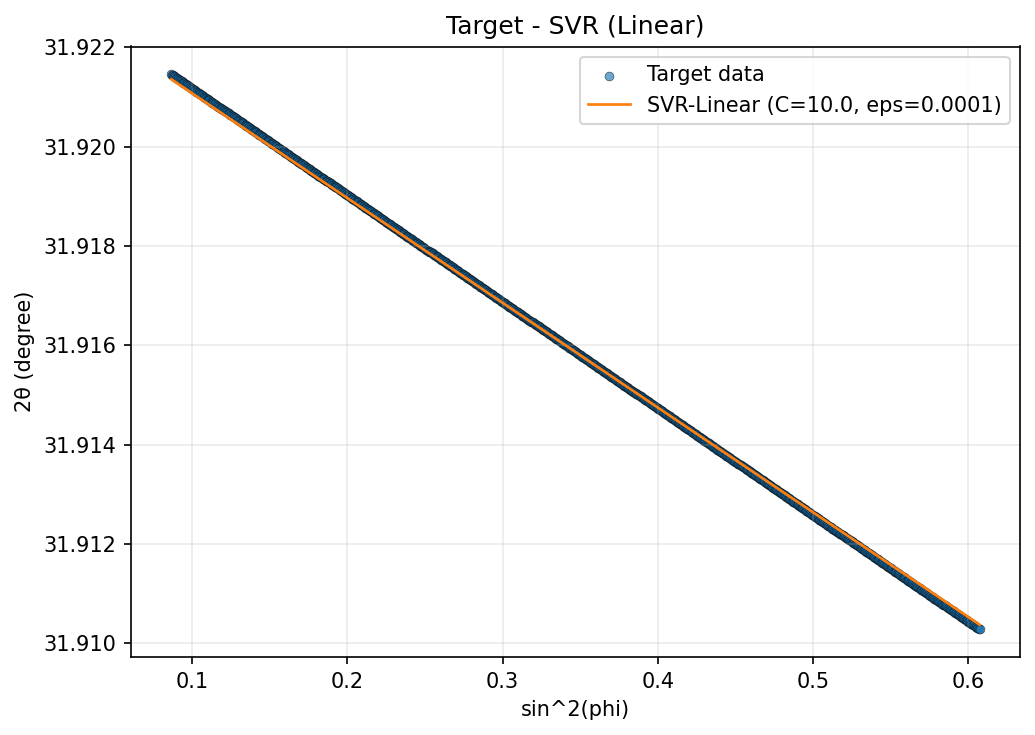


=== CONTROL (SVR-Linear) ===
Params: C=10.0, epsilon=0.0001
SSE = 3.3206314553259454e-06
SAE = 0.049871435311228396


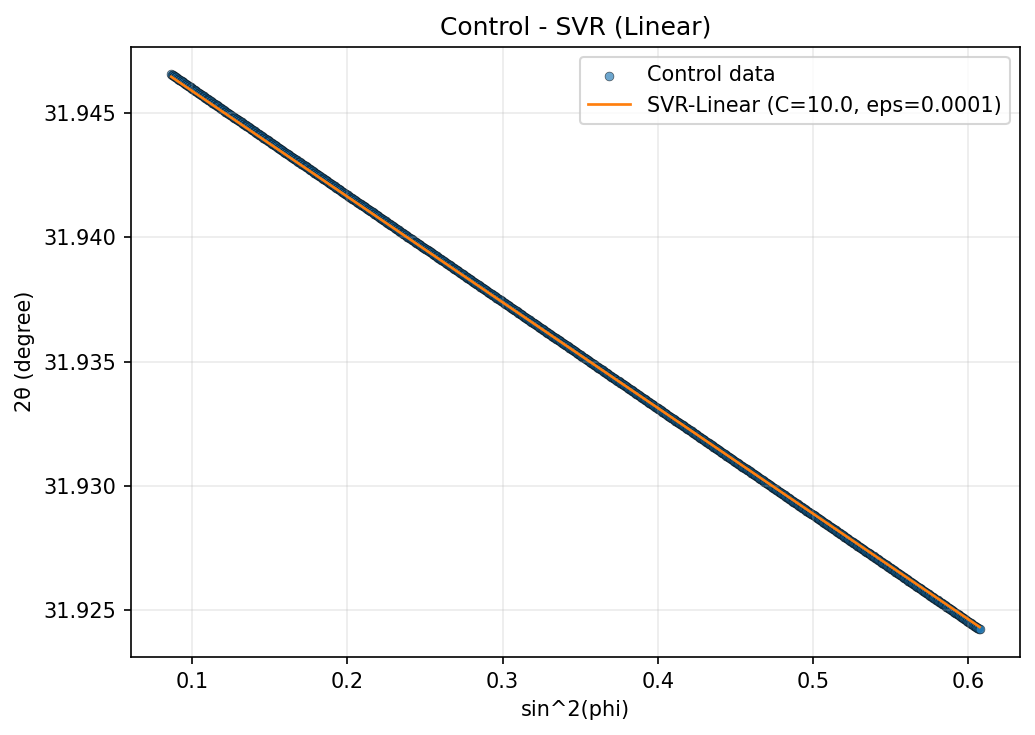

In [19]:

# SVR parameters
C_val = 10.0
epsilon_val = 0.0001

# TARGET: SVR (Linear) fit + metrics + plot
X_t = x_target.reshape(-1, 1)
y_t = y_target

svr_lin_t = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="linear", C=C_val, epsilon=epsilon_val))
])
svr_lin_t.fit(X_t, y_t)

yhat_t = svr_lin_t.predict(X_t)
res_t = y_t - yhat_t
SSE_t = float(np.sum(res_t**2))
SAE_t = float(np.sum(np.abs(res_t)))

print("=== TARGET (SVR-Linear) ===")
print(f"Params: C={C_val}, epsilon={epsilon_val}")
print(f"SSE = {SSE_t}")
print(f"SAE = {SAE_t}")

# plot
xs_t = np.linspace(x_target.min(), x_target.max(), 400).reshape(-1, 1)
ys_t = svr_lin_t.predict(xs_t)

plt.figure(figsize=(7, 5), dpi=150)
plt.scatter(
    x_target, y_target,
    s=18, alpha=0.65,
    color="tab:blue", edgecolors="k", linewidths=0.3,
    label="Target data"
)
plt.plot(
    xs_t.ravel(), ys_t,
    color="tab:orange", linewidth=1.3,
    label=f"SVR-Linear (C={C_val}, eps={epsilon_val})"
)
plt.xlabel("sin^2(phi)")
plt.ylabel("2θ (degree)")
plt.title("Target - SVR (Linear)")
plt.grid(True, alpha=0.25)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


# CONTROL: SVR (Linear) fit + metrics + plot
X_c = x_control.reshape(-1, 1)
y_c = y_control

svr_lin_c = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="linear", C=C_val, epsilon=epsilon_val))
])
svr_lin_c.fit(X_c, y_c)

yhat_c = svr_lin_c.predict(X_c)
res_c = y_c - yhat_c
SSE_c = float(np.sum(res_c**2))
SAE_c = float(np.sum(np.abs(res_c)))

print("\n=== CONTROL (SVR-Linear) ===")
print(f"Params: C={C_val}, epsilon={epsilon_val}")
print(f"SSE = {SSE_c}")
print(f"SAE = {SAE_c}")

# plot
xs_c = np.linspace(x_control.min(), x_control.max(), 400).reshape(-1, 1)
ys_c = svr_lin_c.predict(xs_c)

plt.figure(figsize=(7, 5), dpi=150)
plt.scatter(
    x_control, y_control,
    s=18, alpha=0.65,
    color="tab:blue", edgecolors="k", linewidths=0.3,
    label="Control data"
)
plt.plot(
    xs_c.ravel(), ys_c,
    color="tab:orange", linewidth=1.3,
    label=f"SVR-Linear (C={C_val}, eps={epsilon_val})"
)
plt.xlabel("sin^2(phi)")
plt.ylabel("2θ (degree)")
plt.title("Control - SVR (Linear)")
plt.grid(True, alpha=0.25)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


### RBF

=== TARGET (RBF - KernelRidge) ===
Params: alpha=1e-06, gamma=0.1
SSE = 1.733987143671522e-05
SAE = 0.10149372302436888


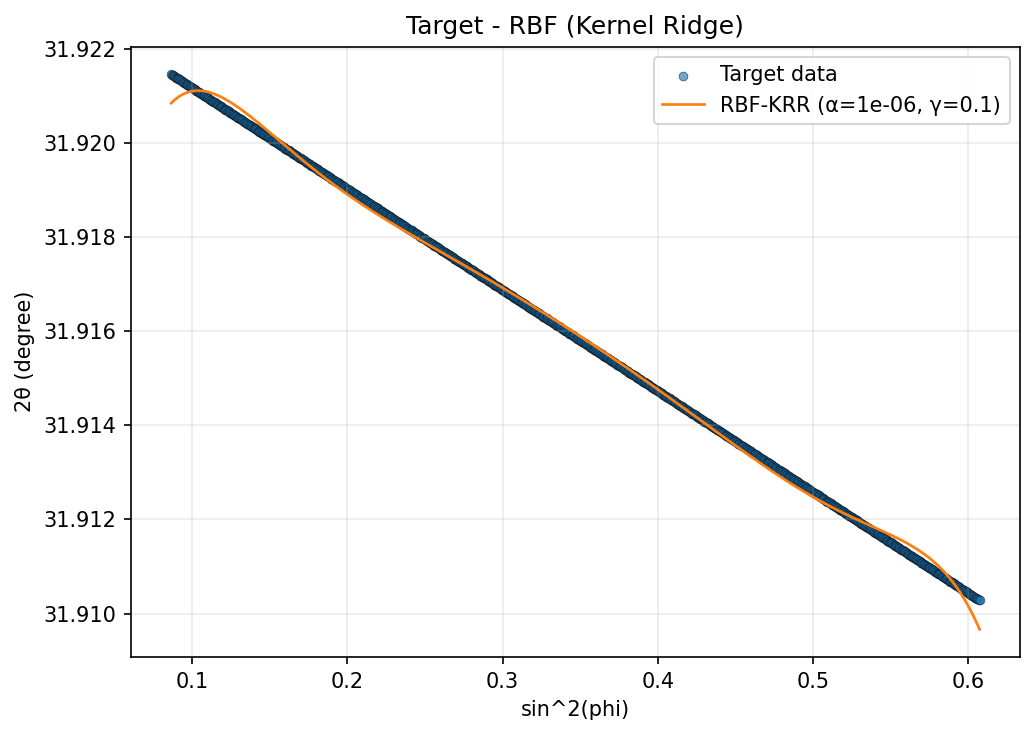


=== CONTROL (RBF - KernelRidge) ===
Params: alpha=1e-06, gamma=0.1
SSE = 1.7363393937604416e-05
SAE = 0.10156704960482799


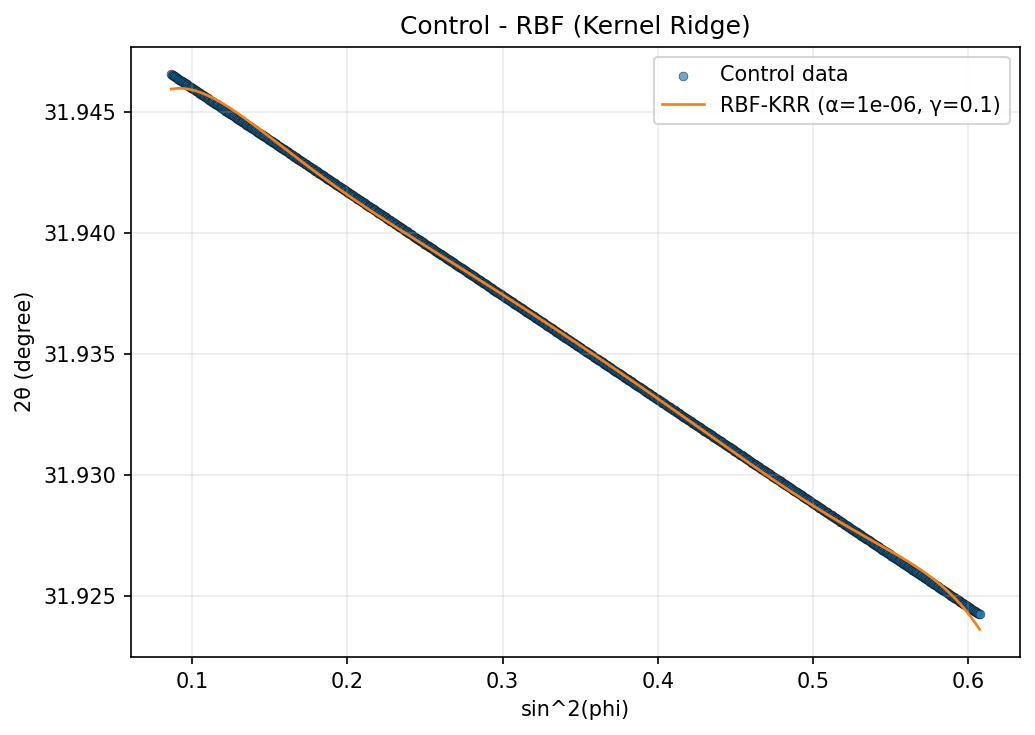

In [20]:

# RBF Parameters

alpha_val = 1e-6   # regularization
gamma_val = 0.1    # RBF width control

# TARGET: RBF (Kernel Ridge) fit + metrics + plot
X_t = x_target.reshape(-1, 1)
y_t = y_target

rbf_t = Pipeline([
    ("scaler", StandardScaler()),
    ("krr", KernelRidge(kernel="rbf", alpha=alpha_val, gamma=gamma_val))
])
rbf_t.fit(X_t, y_t)

yhat_t = rbf_t.predict(X_t)
res_t = y_t - yhat_t
SSE_t = float(np.sum(res_t**2))
SAE_t = float(np.sum(np.abs(res_t)))

print("=== TARGET (RBF - KernelRidge) ===")
print(f"Params: alpha={alpha_val}, gamma={gamma_val}")
print(f"SSE = {SSE_t}")
print(f"SAE = {SAE_t}")

# plot
xs_t = np.linspace(x_target.min(), x_target.max(), 400).reshape(-1, 1)
ys_t = rbf_t.predict(xs_t)

plt.figure(figsize=(7, 5), dpi=150)
plt.scatter(
    x_target, y_target,
    s=18, alpha=0.65, color="tab:blue",
    edgecolors="k", linewidths=0.3,
    label="Target data"
)
plt.plot(
    xs_t.ravel(), ys_t,
    color="tab:orange", linewidth=1.3,
    label=f"RBF-KRR (α={alpha_val}, γ={gamma_val})"
)
plt.xlabel("sin^2(phi)")
plt.ylabel("2θ (degree)")
plt.title("Target - RBF (Kernel Ridge)")
plt.grid(True, alpha=0.25)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


# CONTROL: RBF (Kernel Ridge) fit + metrics + plot
X_c = x_control.reshape(-1, 1)
y_c = y_control

rbf_c = Pipeline([
    ("scaler", StandardScaler()),
    ("krr", KernelRidge(kernel="rbf", alpha=alpha_val, gamma=gamma_val))
])
rbf_c.fit(X_c, y_c)

yhat_c = rbf_c.predict(X_c)
res_c = y_c - yhat_c
SSE_c = float(np.sum(res_c**2))
SAE_c = float(np.sum(np.abs(res_c)))

print("\n=== CONTROL (RBF - KernelRidge) ===")
print(f"Params: alpha={alpha_val}, gamma={gamma_val}")
print(f"SSE = {SSE_c}")
print(f"SAE = {SAE_c}")

# plot
xs_c = np.linspace(x_control.min(), x_control.max(), 400).reshape(-1, 1)
ys_c = rbf_c.predict(xs_c)

plt.figure(figsize=(7, 5), dpi=150)
plt.scatter(
    x_control, y_control,
    s=18, alpha=0.65, color="tab:blue",
    edgecolors="k", linewidths=0.3,
    label="Control data"
)
plt.plot(
    xs_c.ravel(), ys_c,
    color="tab:orange", linewidth=1.3,
    label=f"RBF-KRR (α={alpha_val}, γ={gamma_val})"
)
plt.xlabel("sin^2(phi)")
plt.ylabel("2θ (degree)")
plt.title("Control - RBF (Kernel Ridge)")
plt.grid(True, alpha=0.25)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()
